In [1]:
# Import important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score


In [16]:
df = pd.read_csv("/content/telecom_customer_churn.csv")

df.head()

#Uploaded the dataset but i can see some missing values.

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,37,Yes,0,2,9,NaN,Yes,42.39,No,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,Male,46,No,0,0,9,NaN,Yes,10.69,Yes,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,Male,50,No,0,0,4,Offer E,Yes,33.65,No,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,Male,78,Yes,0,1,13,Offer D,Yes,27.82,No,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,Female,75,Yes,0,3,3,NaN,Yes,7.38,No,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


In [18]:
df['Customer Status'] = df['Customer Status'].str.strip()


#removed the spaces in target variable like "churned " so that i can encode them all together.

In [19]:
df['Customer Status'] = df['Customer Status'].map({
    'Churned':1,
    'Stayed':0,
    'Joined':0
})

#as the ML works on numerical data so converted the target classes in 0 and 1

In [20]:
df['Customer Status'].value_counts()

#show the amound of enteries of  (stayed/joined = 0) and (churned = 1)

,count
Customer Status,
0,5174
1,1869


In [21]:
df.isnull().sum()

#check and found missing values in columns (Offer, Internet type) etc.

,0
Gender,0
Age,0
Married,0
Number of Dependents,0
Number of Referrals,0
Tenure in Months,0
Offer,3877
Phone Service,0
Avg Monthly Long Distance Charges,682
Multiple Lines,682


In [22]:
# Separated numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical columns with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


#first separated the numercial and categorical datatype columns and then filled the categorial with mode and the numerical with mean.

In [23]:
df.isnull().sum()

#rechecked and now no missing value.

,0
Gender,0
Age,0
Married,0
Number of Dependents,0
Number of Referrals,0
Tenure in Months,0
Offer,0
Phone Service,0
Avg Monthly Long Distance Charges,0
Multiple Lines,0


In [26]:
df.shape

#show 7043 customers and 37 features.

(7043, 37)

In [24]:
#encoded categorical columns:

df = pd.get_dummies(df, drop_first=True)

#converted columnes like Gender (male/female etc) into numeric featuers as ML models cannot read text

#Ex:
# 0 = Female
# 1 = Male

In [29]:
df = df.astype({col: 'int64' for col in df.select_dtypes('bool').columns})

#converted the boolean columns to 0/1 like told above (0 = female and 1 = male) did for all cateogrical column which were converted to boolean


In [33]:
X = df.drop('Customer Status', axis=1)
y = df['Customer Status']
y.head()

#separated the features and target variable and defined it.

,Customer Status
0,0
1,0
2,1
3,1
4,1


In [34]:
#Train and Test Split:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape
#shows the training split from total data.

(5634, 36)

In [32]:
#Model Training:

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
#predictions:

y_pred = model.predict(X_test)
y_pred[:10]

# 0 = stayed
# 1 = chruned

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0])

In [38]:
#Evaluation:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

#Out of all customers, the model correctly predicted churn or stay 76.8% of the time.
#recall = how many churners were detected
#precision = predicted churners that were correct
#f1 score = balance of prediction and recall

Accuracy: 0.7679205110007097
Precision: 0.5608465608465608
Recall: 0.5683646112600537
F1 Score: 0.5645805592543276


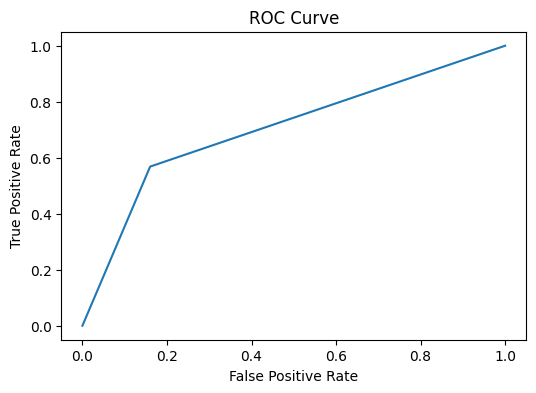

In [39]:
#ROC CURVE

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

#Roc tells basically how well it has classified between the churened and non churened.

#FPR = tells the customers where predicted to churn but didnt
#TPR = predicted churners that were correct

#Justification:

#The model uses a default probability threshold of 0.5 to classify customers as churned or retained.
#Customers with a predicted churn probability greater than 0.5 are classified as churners,
#while those below the threshold are classified as retained customers.

In [40]:
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

#AUC = measures the overall performance of the classifier.
#70% tells that the model has good ability to distinguish churn vs non-churn customers

ROC AUC Score: 0.7040664755141968


In [41]:
#feature Importance:

importance = pd.Series(model.feature_importances_, index=X.columns)

top_features = importance.sort_values(ascending=False).head(5)

print(top_features)

#tells which features has more importance in prediction

Age                    0.115536
Monthly Charge         0.112429
Contract_Two Year      0.111297
Contract_One Year      0.103635
Number of Referrals    0.083383
dtype: float64


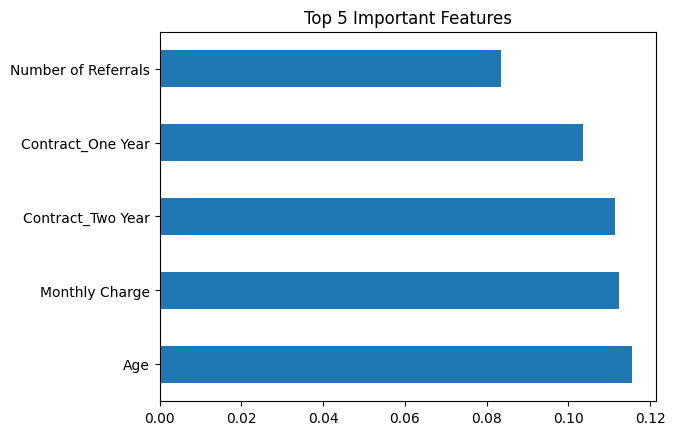

In [44]:
top_features.plot(kind='barh')
plt.title("Top 5 Important Features")
plt.show()


#SHOWS:

#Higher value = more influence.

#ex:
#Higher bills often lead to churn
